In [1]:
# ============================================================
# YAPAY ZEKA DESTEKLİ LOJİSTİK ANAHAT OPTİMİZASYONU
# GELİŞMİŞ ÇÖZÜM AŞAMASI
# Sanka Takımı | TEKNOFEST 2026
# ============================================================
# Kullanılan Yöntemler:
#   - Talep Tahmini : LightGBM + Walk Forward Validation
#   - Optimizasyon  : Greedy + Kapasiteye Göre Araç Seçimi
#   - Kısıtlar      : Tır kapasitesi, Elleçleme, SLA
# ============================================================

# Kütüphane kurulumu
!pip install lightgbm -q

# Import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from google.colab import files

print("✅ Tüm kütüphaneler yüklendi!")
print("   Python ortamı hazır.")

✅ Tüm kütüphaneler yüklendi!
   Python ortamı hazır.


In [2]:
# ============================================================
# VERİ YÜKLEME
# Gerekli dosyalar /content/ dizinine yüklenmiş olmalıdır:
#   - teknofest26_gelismis.xlsx  : Geçmiş talep verisi
#   - sehirler_arasi_lojistik.xlsx : Mesafe, süre, SLA matrisi
#   - Kiralık_Araclar.xlsx       : Kiralık araç rotaları
#   - Arac_Kapasite_Maliyet_Saat.xlsx : Araç kapasite ve maliyetleri
#   - Ellecleme-kapasite.xlsx    : TM elleçleme kapasiteleri
#   - tir_kapasiteleri_v2.xlsx   : TM günlük tır kapasiteleri
# ============================================================

df_talep = pd.read_excel('/content/teknofest26_gelismis.xlsx')
df_matris = pd.read_excel('/content/sehirler_arasi_lojistik.xlsx')
df_kira   = pd.read_excel('/content/Kiralık_Araclar.xlsx')
df_arac   = pd.read_excel('/content/Arac_Kapasite_Maliyet_Saat.xlsx')
df_ellec  = pd.read_excel('/content/Ellecleme-kapasite.xlsx')
df_tir    = pd.read_excel('/content/tir_kapasiteleri_v2.xlsx')

df_talep['tarih'] = pd.to_datetime(df_talep['tarih'])

print("✅ Tüm veriler yüklendi!")
print(f"\n  Geçmiş talep : {len(df_talep):>6} satır | "
      f"{df_talep['tarih'].min().date()} → {df_talep['tarih'].max().date()}")
print(f"  OD pair      : {df_talep.groupby(['cikis','varis']).ngroups}")
print(f"  Matris       : {len(df_matris):>6} rota")
print(f"  Kiralık araç : {len(df_kira):>6} rota")
print(f"  Araç tipi    : {len(df_arac):>6} tip")
print(f"  TM sayısı    : {len(df_tir):>6} adet")

✅ Tüm veriler yüklendi!

  Geçmiş talep :  66024 satır | 2026-01-01 → 2026-06-28
  OD pair      : 289
  Matris       :    306 rota
  Kiralık araç :     12 rota
  Araç tipi    :      4 tip
  TM sayısı    :     18 adet


In [3]:
# ============================================================
# YARDIMCI SÖZLÜKLER VE FONKSİYONLAR
# ============================================================

# Matris sözlüğü: (cikis, varis) → {km, süreler, SLA}
matris_dict = {}
for _, r in df_matris.iterrows():
    matris_dict[(r['cikis'], r['varis'])] = {
        'km'           : r['mesafe_km'],
        'tir_sure'     : r['Tir_Suresi_Saat'],
        'kamyon_sure'  : r['Kamyon_Suresi_Saat'],
        'hafif_sure'   : r['Hafif_Kamyon_Suresi_Saat'],
        'kamyonet_sure': r['Kamyonet_Suresi_Saat'],
        'sla_gun'      : r['hedef_teslim_gun'],
    }

# Araç bilgileri sözlüğü
arac_dict = {}
for _, r in df_arac.iterrows():
    arac_dict[r['Araç Adı']] = {
        'kapasite'     : r['Kapasite (desi)'],
        'kiralik_saat' : r['Kiralık Araç Saatlik Kira (TL)'],
        'kiralik_km'   : r['Kiralık Araç Kilometre Başına Maliyet (TL)'],
        'spot_saat'    : r['Spot Araç Saatlik Kira (TL)'],
        'spot_km'      : r['Spot Kilometre Başına Maliyet (TL)'],
    }

# Elleçleme ve tır kapasitesi sözlükleri
ellec_dict = df_ellec.set_index('transfer_merkezi')['ellecleme_kapasite'].to_dict()
tir_dict   = df_tir.set_index('transfer_merkezi')['tir_kapasitesi'].to_dict()

# Kiralık araç bilgileri
kiralik_bilgi = {}
for _, r in df_kira.iterrows():
    key = (r['Çıkış Transfer Merkezi'], r['Varış Transfer Merkezi'])
    if key not in kiralik_bilgi:
        kiralik_bilgi[key] = []
    kiralik_bilgi[key].append({
        'tip' : r['Araç Türü'],
        'adet': r['Araç sayısı']
    })

# Araç türü → süre sütunu eşleştirmesi
sure_map = {
    'Tır'         : 'tir_sure',
    'Kamyon'      : 'kamyon_sure',
    'Hafif Kamyon': 'hafif_sure',
    'Kamyonet'    : 'kamyonet_sure'
}

# ── YARDIMCI FONKSİYONLAR ───────────────────────────────────

def mesafe_km(cikis, varis):
    """İki TM arası mesafe (km)"""
    return matris_dict.get((cikis, varis), {}).get('km', 500)

def yolculuk_sure_dk(cikis, varis, arac_tipi):
    """Yolculuk süresi (dakika, ceil ile yuvarlanmış)"""
    m = matris_dict.get((cikis, varis), {})
    return math.ceil(m.get(sure_map.get(arac_tipi, 'tir_sure'), 5) * 60)

def ellec_sure_dk(desi):
    """Elleçleme süresi (dakika, ceil ile yuvarlanmış)
    Formül: desi × 0.01 dakika"""
    return math.ceil(desi * 0.01)

def sla_sure_dk(cikis, varis):
    """SLA süresi (dakika)"""
    return matris_dict.get((cikis, varis), {}).get('sla_gun', 2) * 24 * 60

def dk_to_hhmm(dk):
    """Dakikayı HH:MM formatına çevir"""
    dk = int(dk)
    return f"{dk//60:02d}:{dk%60:02d}"

def arac_maliyet_hesapla(arac_turu, desi, cikis, varis, kiralik=False):
    """
    Araç toplam maliyetini hesapla.
    Formül: (Saatlik Kira × Kullanım Süresi) + (Mesafe × Km Maliyeti)
    Kullanım Süresi = Çıkış Elleçleme + Yolculuk + Varış Elleçleme
    Tüm süreler ceil ile yuvarlanır.
    """
    bilgi    = arac_dict[arac_turu]
    km       = mesafe_km(cikis, varis)
    yol_dk   = yolculuk_sure_dk(cikis, varis, arac_turu)
    ell_dk   = ellec_sure_dk(desi)
    top_dk   = ell_dk + yol_dk + ell_dk   # çıkış + yol + varış
    top_saat = top_dk / 60

    if kiralik:
        maliyet = (bilgi['kiralik_saat'] * top_saat) + (km * bilgi['kiralik_km'])
    else:
        maliyet = (bilgi['spot_saat'] * top_saat) + (km * bilgi['spot_km'])

    return {
        'maliyet'  : round(maliyet, 2),
        'yol_dk'   : yol_dk,
        'cikis_ell': ell_dk,
        'varis_ell': ell_dk,
        'toplam_dk': top_dk,
        'km'       : km,
    }

def sla_ceza_hesapla(desi, baslangic_dk, bitis_dk, cikis, varis):
    """
    SLA cezası hesapla.
    SLA başlangıcı: talep tamamlanma saati
    SLA bitişi: varış TM elleçleme tamamlanma anı
    Gecikme üst tam saate yuvarlanır.
    Formül: Geciken Desi × Gecikme Saat × 0.4 TL
    """
    sla_dk     = sla_sure_dk(cikis, varis)
    gecikme_dk = bitis_dk - baslangic_dk - sla_dk
    if gecikme_dk <= 0:
        return 0.0
    gecikme_saat = math.ceil(gecikme_dk / 60)
    return round(desi * gecikme_saat * 0.4, 2)

def en_ucuz_spot(desi, cikis, varis, tir_kalan):
    """
    Verilen desi miktarı için en ucuz spot araç kombinasyonunu bul.
    Kaç araç gerektiğini hesaplar ve toplam maliyeti minimize eder.
    Tır kapasitesi kısıtını kontrol eder.
    """
    spot_tipler = ['Tır', 'Kamyon', 'Hafif Kamyon', 'Kamyonet']
    en_iyi_mal  = float('inf')
    en_iyi_tip  = None
    en_iyi_adet = 1
    en_iyi_son  = None

    for tip in spot_tipler:
        kap  = arac_dict[tip]['kapasite']
        adet = math.ceil(desi / kap)

        # Tır kapasitesi kontrolü
        if tip == 'Tır':
            if tir_kalan.get(cikis, 0) < adet:
                continue
            if tir_kalan.get(varis, 0) < adet:
                continue

        # Tek araç maliyeti (desi/adet ile hesapla)
        sonuc   = arac_maliyet_hesapla(tip, desi/adet, cikis, varis, kiralik=False)
        toplam  = adet * sonuc['maliyet']

        if toplam < en_iyi_mal:
            en_iyi_mal  = toplam
            en_iyi_tip  = tip
            en_iyi_adet = adet
            en_iyi_son  = sonuc

    return en_iyi_tip, en_iyi_adet, en_iyi_son

print("✅ Yardımcı sözlükler ve fonksiyonlar hazır!")
print(f"\n  Matris rota sayısı : {len(matris_dict)}")
print(f"  Kiralık rota sayısı: {len(kiralik_bilgi)}")
print(f"  Tır kap=0 TM'ler   : "
      f"{[k for k,v in tir_dict.items() if v==0]}")

# Test
print("\n🧪 Fonksiyon testi (İstanbul→Yalova, Tır, 10000 desi):")
s = arac_maliyet_hesapla('Tır', 10000, 'İstanbul', 'Yalova', kiralik=False)
print(f"   Yolculuk : {s['yol_dk']} dk")
print(f"   Elleçleme: {s['cikis_ell']} dk × 2")
print(f"   Toplam dk: {s['toplam_dk']} dk")
print(f"   Maliyet  : {s['maliyet']:,.2f} TL")

✅ Yardımcı sözlükler ve fonksiyonlar hazır!

  Matris rota sayısı : 306
  Kiralık rota sayısı: 12
  Tır kap=0 TM'ler   : ['Kütahya', 'Isparta', 'Bilecik', 'Zonguldak', 'Sivas', 'Karaman', 'Denizli']

🧪 Fonksiyon testi (İstanbul→Yalova, Tır, 10000 desi):
   Yolculuk : 56 dk
   Elleçleme: 100 dk × 2
   Toplam dk: 256 dk
   Maliyet  : 3,580.00 TL


Tespit edilen anormal günler: 14
  2026-01-01 Per →    184,113 desi (%23)
  2026-01-31 Cmt →      7,852 desi (%1)
  2026-02-28 Cmt →     14,843 desi (%3)
  2026-03-20 Cum →     17,766 desi (%2)
  2026-03-21 Cmt →     22,803 desi (%4)
  2026-03-31 Sal →     24,059 desi (%2)
  2026-04-30 Per →      8,622 desi (%1)
  2026-05-01 Cum →     86,753 desi (%11)
  2026-05-26 Sal →    193,306 desi (%19)
  2026-05-27 Çar →        104 desi (%0)
  2026-05-28 Per →        105 desi (%0)
  2026-05-29 Cum →      3,077 desi (%0)
  2026-05-30 Cmt →     42,971 desi (%8)
  2026-05-31 Paz →      2,010 desi (%2)

Orijinal :  66024 satır
Çıkarılan:    880 satır
Temiz    :  65144 satır ✅


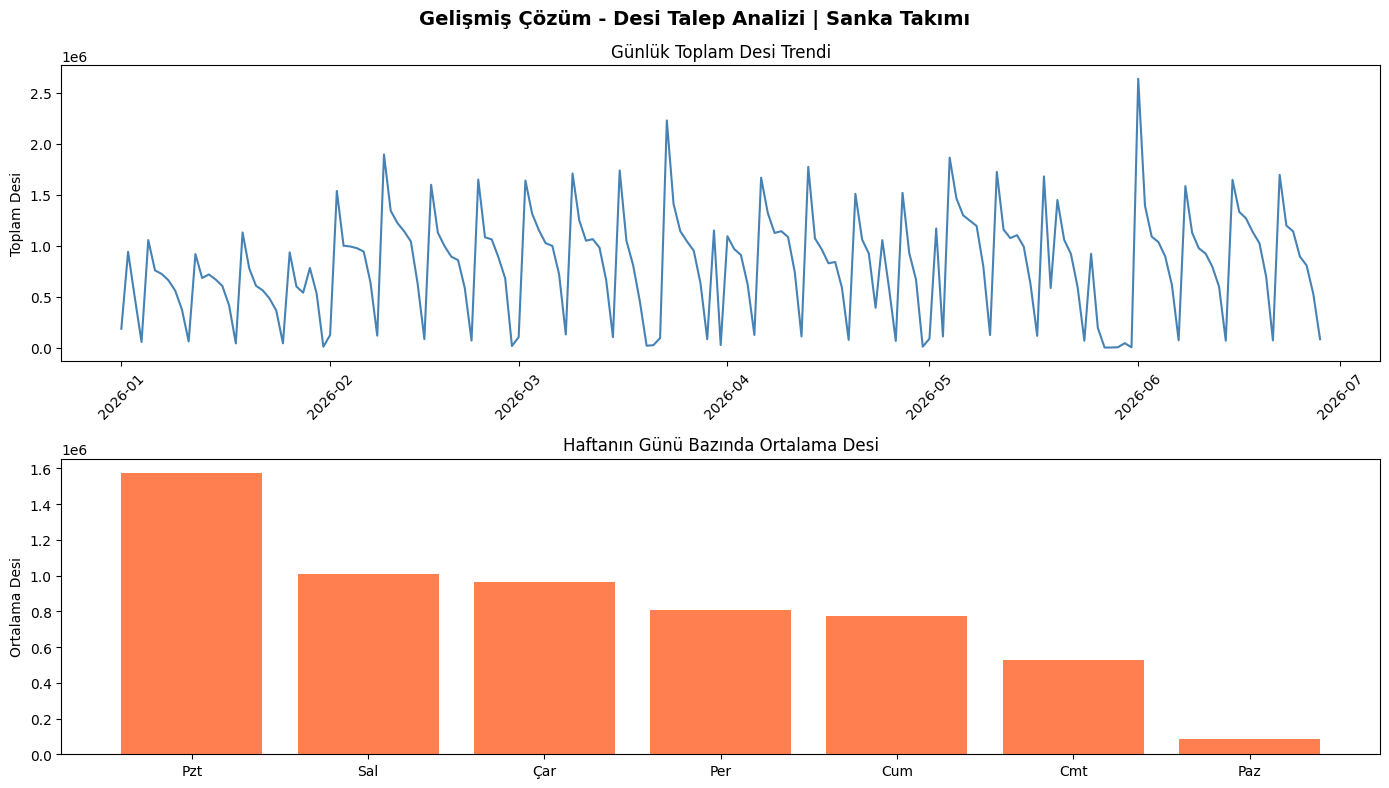

✅ EDA tamamlandı!


In [4]:
# ============================================================
# KEŞİFSEL VERİ ANALİZİ VE ANORMAL GÜN TESPİTİ
# Bayram ve eksik veri günleri modelden çıkarılır.
# Yöntem: Haftanın günü ortalamasının %30'undan düşük günler anormal
# ============================================================

df_talep['saat'] = df_talep['talep_tamamlanma_saati'].apply(
    lambda x: 9 if '9' in str(x) else 17
)
df_talep['haftanin_gunu'] = df_talep['tarih'].dt.dayofweek

# Günlük toplam desi
gunluk = df_talep.groupby('tarih')['toplam_desi'].sum().reset_index()
gunluk['haftanin_gunu'] = gunluk['tarih'].dt.dayofweek

# Haftanın günü ortalaması
gun_ort = gunluk.groupby('haftanin_gunu')['toplam_desi'].mean()
gunluk['gun_ort'] = gunluk['haftanin_gunu'].map(gun_ort)
gunluk['oran']    = gunluk['toplam_desi'] / gunluk['gun_ort']

# %30 eşiğin altındaki günler anormal
anormal = gunluk[gunluk['oran'] < 0.30]['tarih'].tolist()
df_temiz = df_talep[~df_talep['tarih'].isin(anormal)].copy()

print(f"Tespit edilen anormal günler: {len(anormal)}")
gun_adlari = ['Pzt','Sal','Çar','Per','Cum','Cmt','Paz']
for t in anormal:
    gun  = gun_adlari[t.dayofweek]
    desi = gunluk[gunluk['tarih']==t]['toplam_desi'].values[0]
    oran = gunluk[gunluk['tarih']==t]['oran'].values[0]
    print(f"  {t.date()} {gun} → {desi:>10,.0f} desi (%{oran*100:.0f})")

print(f"\nOrijinal : {len(df_talep):>6} satır")
print(f"Çıkarılan: {len(df_talep)-len(df_temiz):>6} satır")
print(f"Temiz    : {len(df_temiz):>6} satır ✅")

# Görselleştirme
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('Gelişmiş Çözüm - Desi Talep Analizi | Sanka Takımı',
             fontsize=14, fontweight='bold')

axes[0].plot(gunluk['tarih'], gunluk['toplam_desi'], color='steelblue', linewidth=1.5)
axes[0].set_title('Günlük Toplam Desi Trendi')
axes[0].set_ylabel('Toplam Desi')
axes[0].tick_params(axis='x', rotation=45)

gun_isimleri = ['Pzt','Sal','Çar','Per','Cum','Cmt','Paz']
axes[1].bar(gun_isimleri, gun_ort.values, color='coral')
axes[1].set_title('Haftanın Günü Bazında Ortalama Desi')
axes[1].set_ylabel('Ortalama Desi')

plt.tight_layout()
plt.savefig('eda_grafik.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA tamamlandı!")

In [5]:
# ============================================================
# FEATURE ENGINEERING
# Modele "ipucu" olacak özellikler üretilir.
# Her OD pair + saat kombinasyonu için ayrı ayrı hesaplanır.
# Lag features: geçmişteki aynı günün değeri
# Rolling features: kayan ortalama ve standart sapma
# ============================================================

df_fe = df_temiz.sort_values(
    ['cikis', 'varis', 'saat', 'tarih']
).copy()

# Zaman özellikleri
df_fe['haftanin_gunu'] = df_fe['tarih'].dt.dayofweek   # 0=Pzt, 6=Paz
df_fe['hafta_no']      = df_fe['tarih'].dt.isocalendar().week.astype(int)
df_fe['ay']            = df_fe['tarih'].dt.month
df_fe['yilin_gunu']    = df_fe['tarih'].dt.dayofyear
df_fe['ayin_gunu']     = df_fe['tarih'].dt.day
df_fe['saat_kodu']     = (df_fe['saat'] == 17).astype(int)  # 09:00=0, 17:00=1

def add_lag_features(group):
    """Her OD pair + saat grubu için lag ve rolling özellikler ekle"""
    group = group.sort_values('tarih').copy()
    # Lag: 7, 14, 21 gün önceki değer
    group['lag_7']           = group['toplam_desi'].shift(7)
    group['lag_14']          = group['toplam_desi'].shift(14)
    group['lag_21']          = group['toplam_desi'].shift(21)
    # Rolling ortalama: son 7 ve 14 günün ortalaması
    group['rolling_mean_7']  = group['toplam_desi'].shift(1).rolling(7).mean()
    group['rolling_mean_14'] = group['toplam_desi'].shift(1).rolling(14).mean()
    # Rolling std: son 7 günün dalgalanması
    group['rolling_std_7']   = group['toplam_desi'].shift(1).rolling(7).std()
    return group

print("Feature engineering yapılıyor...")
df_fe = df_fe.groupby(
    ['cikis', 'varis', 'saat'],
    group_keys=False
).apply(add_lag_features).reset_index(drop=True)

df_fe = df_fe.dropna().reset_index(drop=True)

feature_cols = [
    'haftanin_gunu', 'hafta_no', 'ay', 'yilin_gunu', 'ayin_gunu',
    'saat_kodu',
    'lag_7', 'lag_14', 'lag_21',
    'rolling_mean_7', 'rolling_mean_14', 'rolling_std_7'
]
target_col = 'toplam_desi'

print(f"✅ Feature engineering tamamlandı!")
print(f"  Toplam satır  : {len(df_fe)}")
print(f"  Feature sayısı: {len(feature_cols)}")
print(f"  09:00 satır   : {len(df_fe[df_fe['saat_kodu']==0])}")
print(f"  17:00 satır   : {len(df_fe[df_fe['saat_kodu']==1])}")

Feature engineering yapılıyor...
✅ Feature engineering tamamlandı!
  Toplam satır  : 53398
  Feature sayısı: 12
  09:00 satır   : 18856
  17:00 satır   : 34542


In [6]:
# ============================================================
# TRAIN / VALİDATİON / TEST BÖLÜMÜ + NAİVE BASELİNE
# Zamansal bölüm (shuffle yok — zaman serisi kuralı)
# Train: Başlangıç → 7 Haziran
# Validation: 8 Haziran → 14 Haziran
# Test: 15 Haziran → 28 Haziran
# Naive Baseline: 7 gün önceki değeri tahmin olarak kullan
# ============================================================

train_bitis      = '2026-06-07'
validation_bitis = '2026-06-14'

X_train = df_fe[df_fe['tarih'] <= train_bitis][feature_cols]
y_train = df_fe[df_fe['tarih'] <= train_bitis][target_col]
X_val   = df_fe[(df_fe['tarih'] > train_bitis) &
                (df_fe['tarih'] <= validation_bitis)][feature_cols]
y_val   = df_fe[(df_fe['tarih'] > train_bitis) &
                (df_fe['tarih'] <= validation_bitis)][target_col]
X_test  = df_fe[df_fe['tarih'] > validation_bitis][feature_cols]
y_test  = df_fe[df_fe['tarih'] > validation_bitis][target_col]

print(f"📊 Veri Bölümü:")
print(f"  Train      : {len(X_train):>6} satır")
print(f"  Validation : {len(X_val):>6} satır")
print(f"  Test       : {len(X_test):>6} satır")

def metrik_hesapla(gercek, tahmin, isim):
    mae  = mean_absolute_error(gercek, tahmin)
    rmse = np.sqrt(mean_squared_error(gercek, tahmin))
    mask = gercek > 10
    mape = np.mean(np.abs((gercek[mask]-tahmin[mask])/gercek[mask]))*100
    print(f"  {isim}: MAE={mae:>8,.0f} | RMSE={rmse:>8,.0f} | MAPE=%{mape:.1f}")
    return mae, rmse

# Naive Baseline
df_sorted = df_temiz.sort_values(['cikis','varis','saat','tarih']).copy()
df_sorted['naive'] = df_sorted.groupby(
    ['cikis','varis','saat']
)['toplam_desi'].shift(7)

val_naive  = df_sorted[(df_sorted['tarih'] > train_bitis) &
                        (df_sorted['tarih'] <= validation_bitis)].dropna()
test_naive = df_sorted[df_sorted['tarih'] > validation_bitis].dropna()

print(f"\n📊 Naive Baseline (7 gün önceki değer):")
val_mae_naive, _  = metrik_hesapla(
    val_naive['toplam_desi'].values, val_naive['naive'].values, "Validation")
test_mae_naive, _ = metrik_hesapla(
    test_naive['toplam_desi'].values, test_naive['naive'].values, "Test      ")
print(f"\n  ⚠️ Modelimiz bu değerleri geçmek zorunda!")

📊 Veri Bölümü:
  Train      :  45119 satır
  Validation :   2849 satır
  Test       :   5430 satır

📊 Naive Baseline (7 gün önceki değer):
  Validation: MAE=     978 | RMSE=   2,519 | MAPE=%160.4
  Test      : MAE=     916 | RMSE=   1,956 | MAPE=%101.2

  ⚠️ Modelimiz bu değerleri geçmek zorunda!


🔄 XGBoost eğitiliyor...
🔄 LightGBM eğitiliyor...

MODEL KARŞILAŞTIRMA TABLOSU
Model                   Val MAE   Test MAE
---------------------------------------------
Naive Baseline              978        916
  XGBoost  Val: MAE=     550 | RMSE=   1,439 | MAPE=%82.2
  XGBoost Test: MAE=     741 | RMSE=   1,667 | MAPE=%61.6
  LightGBM Val: MAE=     498 | RMSE=   1,230 | MAPE=%81.3
  LightGBM Test: MAE=     678 | RMSE=   1,506 | MAPE=%67.1

Model                   Val MAE   Test MAE
---------------------------------------------
Naive Baseline              978        916
XGBoost                     550        741
LightGBM                    498        678

🏆 KAZANAN MODEL: LightGBM
   Naive'den iyileşme: %49


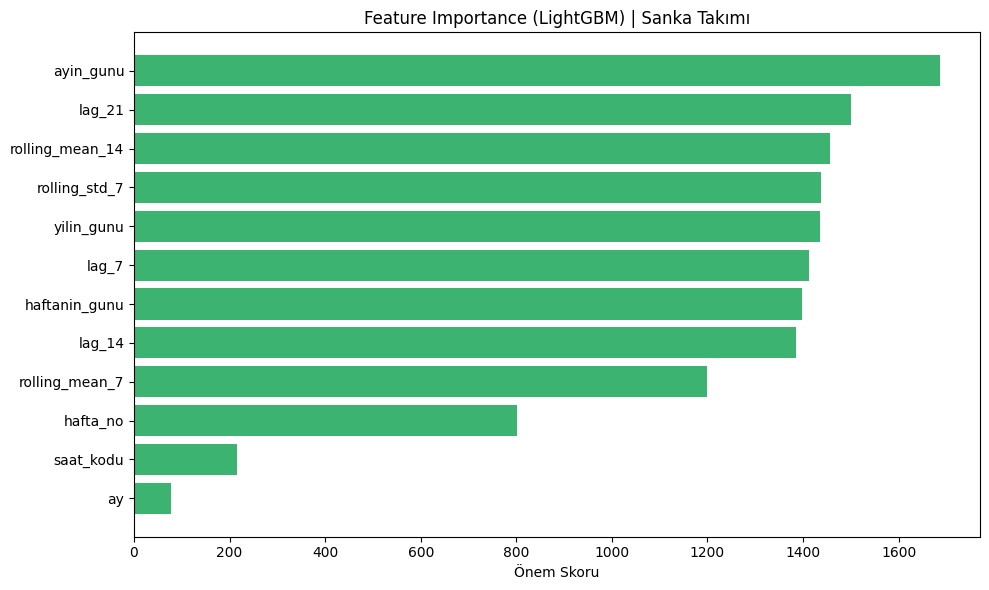

✅ Model karşılaştırması tamamlandı!


In [7]:
# ============================================================
# MODEL EĞİTİMİ VE KARŞILAŞTIRMA
# XGBoost ve LightGBM modelleri eğitilir.
# Validation setinde karşılaştırılır.
# Kazanan model final tahmin için kullanılır.
# ============================================================

# XGBoost
print("🔄 XGBoost eğitiliyor...")
xgb_model = XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbosity=0
)
xgb_model.fit(X_train, y_train)
xgb_val_pred  = np.maximum(xgb_model.predict(X_val), 0)
xgb_test_pred = np.maximum(xgb_model.predict(X_test), 0)

# LightGBM
print("🔄 LightGBM eğitiliyor...")
lgbm_model = LGBMRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbose=-1
)
lgbm_model.fit(X_train, y_train)
lgbm_val_pred  = np.maximum(lgbm_model.predict(X_val), 0)
lgbm_test_pred = np.maximum(lgbm_model.predict(X_test), 0)

# Karşılaştırma
print(f"\n{'='*55}")
print(f"MODEL KARŞILAŞTIRMA TABLOSU")
print(f"{'='*55}")
print(f"{'Model':<20} {'Val MAE':>10} {'Test MAE':>10}")
print(f"{'-'*45}")
print(f"{'Naive Baseline':<20} {val_mae_naive:>10,.0f} {test_mae_naive:>10,.0f}")

xgb_val_mae,  _ = metrik_hesapla(y_val.values,  xgb_val_pred,  "XGBoost  Val")
xgb_test_mae, _ = metrik_hesapla(y_test.values, xgb_test_pred, "XGBoost Test")
lgbm_val_mae,  _ = metrik_hesapla(y_val.values,  lgbm_val_pred,  "LightGBM Val")
lgbm_test_mae, _ = metrik_hesapla(y_test.values, lgbm_test_pred, "LightGBM Test")

print(f"\n{'Model':<20} {'Val MAE':>10} {'Test MAE':>10}")
print(f"{'-'*45}")
print(f"{'Naive Baseline':<20} {val_mae_naive:>10,.0f} {test_mae_naive:>10,.0f}")
print(f"{'XGBoost':<20} {xgb_val_mae:>10,.0f} {xgb_test_mae:>10,.0f}")
print(f"{'LightGBM':<20} {lgbm_val_mae:>10,.0f} {lgbm_test_mae:>10,.0f}")

# Kazanan
if lgbm_val_mae < xgb_val_mae:
    best_model = lgbm_model
    best_name  = "LightGBM"
else:
    best_model = xgb_model
    best_name  = "XGBoost"

print(f"\n🏆 KAZANAN MODEL: {best_name}")
print(f"   Naive'den iyileşme: %{(1-lgbm_val_mae/val_mae_naive)*100:.0f}")

# Feature importance grafiği
fi = pd.Series(best_model.feature_importances_, index=feature_cols)
fi = fi.sort_values(ascending=True)
plt.figure(figsize=(10, 6))
plt.barh(fi.index, fi.values, color='mediumseagreen')
plt.title(f'Feature Importance ({best_name}) | Sanka Takımı')
plt.xlabel('Önem Skoru')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print("✅ Model karşılaştırması tamamlandı!")

Walk Forward Validation başlıyor... (17 pencere)

  Pencere  1 | 2026-03-02 → 2026-03-08 | MAE:      554 | RMSE:    1,202
  Pencere  2 | 2026-03-09 → 2026-03-15 | MAE:      484 | RMSE:      995
  Pencere  3 | 2026-03-16 → 2026-03-22 | MAE:      788 | RMSE:    1,775
  Pencere  4 | 2026-03-23 → 2026-03-29 | MAE:    1,168 | RMSE:    2,873
  Pencere  5 | 2026-03-30 → 2026-04-05 | MAE:      800 | RMSE:    1,923
  Pencere  6 | 2026-04-06 → 2026-04-12 | MAE:      546 | RMSE:    1,171
  Pencere  7 | 2026-04-13 → 2026-04-19 | MAE:      499 | RMSE:    1,129
  Pencere  8 | 2026-04-20 → 2026-04-26 | MAE:      656 | RMSE:    1,577
  Pencere  9 | 2026-04-27 → 2026-05-03 | MAE:      818 | RMSE:    1,749
  Pencere 10 | 2026-05-04 → 2026-05-10 | MAE:      673 | RMSE:    1,434
  Pencere 11 | 2026-05-11 → 2026-05-17 | MAE:      576 | RMSE:    1,192
  Pencere 12 | 2026-05-18 → 2026-05-24 | MAE:      727 | RMSE:    1,740
  Pencere 13 | 2026-05-25 → 2026-05-31 | MAE:    2,178 | RMSE:    4,581
  Pencere 14 |

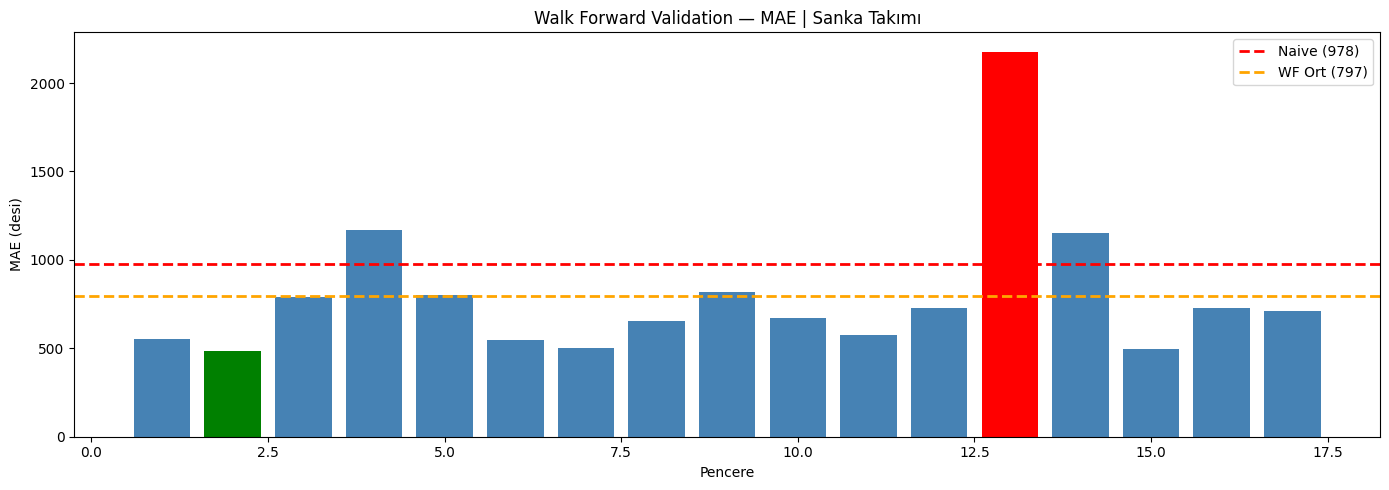

✅ Walk Forward tamamlandı!


In [8]:
# ============================================================
# WALK FORWARD VALIDATION
# Her hafta için model eğitilir ve sonraki hafta tahmin edilir.
# Bu yöntem gerçek operasyonel koşulları simüle eder.
# 17 pencere üzerinde test yapılır.
# ============================================================

MIN_TRAIN_HAFTA = 8
pazartesiler = sorted(df_temiz[
    df_temiz['tarih'].dt.dayofweek == 0
]['tarih'].dt.date.unique())

wf_sonuclar = []
print(f"Walk Forward Validation başlıyor... ({len(pazartesiler)-MIN_TRAIN_HAFTA} pencere)\n")

for i in range(MIN_TRAIN_HAFTA, len(pazartesiler)):
    train_bitis_wf = pd.Timestamp(pazartesiler[i]) - pd.Timedelta(days=1)
    test_bas       = pd.Timestamp(pazartesiler[i])
    test_bit       = test_bas + pd.Timedelta(days=6)

    train_wf = df_fe[df_fe['tarih'] <= train_bitis_wf]
    test_wf  = df_fe[(df_fe['tarih'] >= test_bas) &
                     (df_fe['tarih'] <= test_bit)]

    if len(test_wf) == 0:
        continue

    model_wf = LGBMRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, verbose=-1
    )
    model_wf.fit(train_wf[feature_cols], train_wf[target_col])
    pred_wf = np.maximum(model_wf.predict(test_wf[feature_cols]), 0)
    mae     = mean_absolute_error(test_wf[target_col].values, pred_wf)
    rmse    = np.sqrt(mean_squared_error(test_wf[target_col].values, pred_wf))

    wf_sonuclar.append({
        'Pencere'     : i - MIN_TRAIN_HAFTA + 1,
        'Test Haftası': f"{test_bas.date()} → {test_bit.date()}",
        'MAE'         : round(mae, 0),
        'RMSE'        : round(rmse, 0),
    })
    print(f"  Pencere {i-MIN_TRAIN_HAFTA+1:>2} | "
          f"{test_bas.date()} → {test_bit.date()} | "
          f"MAE: {mae:>8,.0f} | RMSE: {rmse:>8,.0f}")

df_wf = pd.DataFrame(wf_sonuclar)
print(f"\n{'='*55}")
print(f"WALK FORWARD ÖZET")
print(f"{'='*55}")
print(f"  Ortalama MAE : {df_wf['MAE'].mean():>10,.0f} desi")
print(f"  Ortalama RMSE: {df_wf['RMSE'].mean():>10,.0f} desi")
print(f"  En iyi MAE   : {df_wf['MAE'].min():>10,.0f} "
      f"(Pencere {df_wf.loc[df_wf['MAE'].idxmin(),'Pencere']})")
print(f"  En kötü MAE  : {df_wf['MAE'].max():>10,.0f} "
      f"(Pencere {df_wf.loc[df_wf['MAE'].idxmax(),'Pencere']})")
print(f"  Naive vs WF  : {val_mae_naive:,.0f} → {df_wf['MAE'].mean():,.0f} "
      f"(%{(1-df_wf['MAE'].mean()/val_mae_naive)*100:.0f} iyileşme) ✅")

# Grafik
plt.figure(figsize=(14, 5))
renkler = ['red' if m == df_wf['MAE'].max()
           else 'green' if m == df_wf['MAE'].min()
           else 'steelblue' for m in df_wf['MAE']]
plt.bar(df_wf['Pencere'], df_wf['MAE'], color=renkler)
plt.axhline(y=val_mae_naive, color='red', linestyle='--',
            linewidth=2, label=f'Naive ({val_mae_naive:,.0f})')
plt.axhline(y=df_wf['MAE'].mean(), color='orange', linestyle='--',
            linewidth=2, label=f'WF Ort ({df_wf["MAE"].mean():,.0f})')
plt.title('Walk Forward Validation — MAE | Sanka Takımı')
plt.xlabel('Pencere'); plt.ylabel('MAE (desi)')
plt.legend(); plt.tight_layout()
plt.savefig('walk_forward.png', dpi=150)
plt.show()
print("✅ Walk Forward tamamlandı!")

In [9]:
# ============================================================
# FİNAL MODEL + 29 HAZİRAN - 5 TEMMUZ TAHMİNİ
# Tüm temiz veriyle LightGBM yeniden eğitilir.
# 29 Haziran 09:00 → 5 Temmuz 17:00 için tahmin üretilir.
# Sağlık kontrolü: uç değerler geçmiş ortalamayla düzeltilir.
# ============================================================

# Tüm veriyle final model eğit
print("🔄 Final model tüm veriyle eğitiliyor...")
final_model = LGBMRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbose=-1
)
final_model.fit(df_fe[feature_cols], df_fe[target_col])
print("✅ Final model hazır!")

# Tahmin tarihleri ve OD pairler
target_dates = pd.date_range('2026-06-29', '2026-07-05', freq='D')
saatler      = [9, 17]
od_pairs     = df_talep[['cikis','varis']].drop_duplicates()

tahmin_listesi = []
talep_id_sayac = 66025  # Geçmiş verinin devamından başla (D66025)

for _, od in od_pairs.iterrows():
    cikis = od['cikis']
    varis = od['varis']

    for saat in saatler:
        od_gecmis = df_temiz[
            (df_temiz['cikis'] == cikis) &
            (df_temiz['varis'] == varis) &
            (df_temiz['saat'] == saat)
        ].sort_values('tarih').set_index('tarih')['toplam_desi']

        for tarih in target_dates:
            def get_lag(n):
                t = tarih - pd.Timedelta(days=n)
                return od_gecmis[t] if t in od_gecmis.index else od_gecmis.mean()

            son_7  = od_gecmis[(od_gecmis.index >= tarih-pd.Timedelta(days=8)) &
                                (od_gecmis.index < tarih)]
            son_14 = od_gecmis[(od_gecmis.index >= tarih-pd.Timedelta(days=15)) &
                                (od_gecmis.index < tarih)]

            tahmin_listesi.append({
                'talep_id'       : f"D{talep_id_sayac:05d}",
                'cikis'          : cikis,
                'varis'          : varis,
                'tarih'          : tarih.date(),
                'saat'           : saat,
                'haftanin_gunu'  : tarih.dayofweek,
                'hafta_no'       : tarih.isocalendar()[1],
                'ay'             : tarih.month,
                'yilin_gunu'     : tarih.dayofyear,
                'ayin_gunu'      : tarih.day,
                'saat_kodu'      : 1 if saat == 17 else 0,
                'lag_7'          : get_lag(7),
                'lag_14'         : get_lag(14),
                'lag_21'         : get_lag(21),
                'rolling_mean_7' : son_7.mean()  if len(son_7)  > 0 else od_gecmis.mean(),
                'rolling_mean_14': son_14.mean() if len(son_14) > 0 else od_gecmis.mean(),
                'rolling_std_7'  : son_7.std()   if len(son_7)  > 1 else 0,
            })
            talep_id_sayac += 1

df_tahmin = pd.DataFrame(tahmin_listesi)
df_tahmin['tahmin_desi'] = np.maximum(
    final_model.predict(df_tahmin[feature_cols]), 0
)

# Sağlık kontrolü: geçmiş ortalamanın %20'sinden düşük
# veya 3 katından yüksek tahminleri düzelt
od_gun_ort = df_temiz.groupby([
    'cikis', 'varis', df_temiz['tarih'].dt.dayofweek, 'saat'
])['toplam_desi'].mean().reset_index()
od_gun_ort.columns = ['cikis','varis','haftanin_gunu','saat','gecmis_ort']

df_tahmin = df_tahmin.merge(
    od_gun_ort,
    on=['cikis','varis','haftanin_gunu','saat'], how='left'
)

def saglik_kontrolu(row):
    t = row['tahmin_desi']
    g = row['gecmis_ort']
    if pd.isna(g) or g == 0:
        return t
    if t < g * 0.20 or t > g * 3.00:
        return g
    return t

df_tahmin['tahmin_desi'] = df_tahmin.apply(saglik_kontrolu, axis=1)

# Sıfır tahminleri geçmiş ortalamayla doldur
for idx, row in df_tahmin[df_tahmin['tahmin_desi']==0].iterrows():
    gun = pd.Timestamp(row['tarih']).dayofweek
    gecmis_gun = df_temiz[
        (df_temiz['cikis']==row['cikis']) &
        (df_temiz['varis']==row['varis']) &
        (df_temiz['saat']==row['saat']) &
        (df_temiz['tarih'].dt.dayofweek==gun)
    ]['toplam_desi']
    if len(gecmis_gun) > 0:
        df_tahmin.at[idx, 'tahmin_desi'] = gecmis_gun.mean()

# Günlük özet
print("\n📦 29 Haziran - 5 Temmuz Tahmin Özeti:")
gun_adlari = ['Pazartesi','Salı','Çarşamba','Perşembe','Cuma','Cumartesi','Pazar']
gunluk = df_tahmin.groupby('tarih')['tahmin_desi'].sum()
for tarih, desi in gunluk.items():
    gun = gun_adlari[pd.Timestamp(tarih).dayofweek]
    print(f"  {tarih}  {gun:<12} →  {desi:>12,.0f} desi")
print(f"\n  📊 Haftalık TOPLAM : {gunluk.sum():>12,.0f} desi")
print(f"  Satır sayısı      : {len(df_tahmin)}")
print(f"  Sıfır desi        : {(df_tahmin['tahmin_desi']==0).sum()}")

🔄 Final model tüm veriyle eğitiliyor...
✅ Final model hazır!

📦 29 Haziran - 5 Temmuz Tahmin Özeti:
  2026-06-29  Pazartesi    →     1,105,295 desi
  2026-06-30  Salı         →       819,375 desi
  2026-07-01  Çarşamba     →     1,029,688 desi
  2026-07-02  Perşembe     →       868,023 desi
  2026-07-03  Cuma         →       700,400 desi
  2026-07-04  Cumartesi    →       504,626 desi
  2026-07-05  Pazar        →       150,403 desi

  📊 Haftalık TOPLAM :    5,177,808 desi
  Satır sayısı      : 4046
  Sıfır desi        : 40


In [10]:
# ============================================================
# TAHMİN EXCEL ÇIKTISI
# Şartname formatı:
# Talep ID | Tarih | Talep Tamamlama Saati |
# Çıkış Transfer Merkezi | Varış Transfer Merkezi |
# Tahmin Edilen Desi
# ============================================================

# Şartname formatına getir
df_tahmin_cikti = df_tahmin[[
    'talep_id', 'tarih', 'saat', 'cikis', 'varis', 'tahmin_desi'
]].copy()

df_tahmin_cikti.columns = [
    'Talep ID', 'Tarih', 'Talep Tamamlama Saati',
    'Çıkış Transfer Merkezi', 'Varış Transfer Merkezi',
    'Tahmin Edilen Desi'
]

# Tarih formatı: gün.ay.yıl
df_tahmin_cikti['Tarih'] = pd.to_datetime(
    df_tahmin_cikti['Tarih']
).dt.strftime('%d.%m.%Y')

# Saat formatı: SS:DD:SS
df_tahmin_cikti['Talep Tamamlama Saati'] = df_tahmin_cikti[
    'Talep Tamamlama Saati'
].apply(lambda x: '09:00:00' if x == 9 else '17:00:00')

# Desi yuvarlama
df_tahmin_cikti['Tahmin Edilen Desi'] = df_tahmin_cikti[
    'Tahmin Edilen Desi'
].round(2)

# Kronolojik sıralama
df_tahmin_cikti['Tarih_sort'] = pd.to_datetime(
    df_tahmin_cikti['Tarih'], format='%d.%m.%Y'
)
df_tahmin_cikti = df_tahmin_cikti.sort_values([
    'Tarih_sort', 'Çıkış Transfer Merkezi',
    'Varış Transfer Merkezi', 'Talep Tamamlama Saati'
]).drop('Tarih_sort', axis=1).reset_index(drop=True)

# Kontrol
print("✅ Talep Tahmini Özeti:")
print(f"  Satır sayısı     : {len(df_tahmin_cikti)}")
print(f"  Sütunlar         : {df_tahmin_cikti.columns.tolist()}")
print(f"  Tarih aralığı    : {df_tahmin_cikti['Tarih'].iloc[0]} → {df_tahmin_cikti['Tarih'].iloc[-1]}")
print(f"  Saat değerleri   : {df_tahmin_cikti['Talep Tamamlama Saati'].unique().tolist()}")
print(f"  Toplam desi      : {df_tahmin_cikti['Tahmin Edilen Desi'].sum():,.0f}")
print(f"  Sıfır desi       : {(df_tahmin_cikti['Tahmin Edilen Desi']==0).sum()}")
print(f"  Negatif desi     : {(df_tahmin_cikti['Tahmin Edilen Desi']<0).sum()}")
print(f"  ID aralığı       : {df_tahmin_cikti['Talep ID'].min()} → {df_tahmin_cikti['Talep ID'].max()}")

print(f"\nİlk 3 satır:")
print(df_tahmin_cikti.head(3).to_string(index=False))

# Kaydet
df_tahmin_cikti.to_excel('SANKA_talep_tahmini_FINAL.xlsx', index=False)
print("\n✅ SANKA_talep_tahmini_FINAL.xlsx kaydedildi!")
files.download('SANKA_talep_tahmini_FINAL.xlsx')

✅ Talep Tahmini Özeti:
  Satır sayısı     : 4046
  Sütunlar         : ['Talep ID', 'Tarih', 'Talep Tamamlama Saati', 'Çıkış Transfer Merkezi', 'Varış Transfer Merkezi', 'Tahmin Edilen Desi']
  Tarih aralığı    : 29.06.2026 → 05.07.2026
  Saat değerleri   : ['09:00:00', '17:00:00']
  Toplam desi      : 5,177,809
  Sıfır desi       : 40
  Negatif desi     : 0
  ID aralığı       : D66025 → D70070

İlk 3 satır:
Talep ID      Tarih Talep Tamamlama Saati Çıkış Transfer Merkezi Varış Transfer Merkezi  Tahmin Edilen Desi
  D68125 29.06.2026              09:00:00              Balıkesir                Bilecik               96.25
  D68132 29.06.2026              17:00:00              Balıkesir                Bilecik             3479.86
  D68139 29.06.2026              09:00:00              Balıkesir                Denizli               25.46

✅ SANKA_talep_tahmini_FINAL.xlsx kaydedildi!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
# ============================================================
# OPTİMİZASYON — SPOT ARAÇ PLANLAMASI
# Strateji:
#   1. Kiralık araçlar önce kullanılır (zorunlu)
#   2. Aynı rotada 09:00 + 17:00 talepleri birleştirilir
#   3. Kalan talep için en ucuz spot araç seçilir
#   4. Tır kapasitesi kısıtı kontrol edilir
#   5. Maliyet = (Saatlik Kira × Kullanım Süresi) + (Km × Km Maliyeti)
#   6. Maliyet desi oranında dağıtılır (şartname gereği)
# ============================================================

# Tahmin verisini hazırla
df_tahmin['Tarih_dt'] = pd.to_datetime(df_tahmin['tarih'])
spot_tipler = ['Tır', 'Kamyon', 'Hafif Kamyon', 'Kamyonet']

arac_id_sayac  = 1
plan_listesi   = []
toplam_maliyet = 0

print("Optimizasyon başlıyor...\n")

for tarih in sorted(df_tahmin['Tarih_dt'].unique()):
    tarih_str  = tarih.strftime('%d.%m.%Y')
    gun_tahmin = df_tahmin[df_tahmin['Tarih_dt'] == tarih].copy()

    # Günlük tır kapasitesi sıfırla
    tir_kalan  = {tm: tir_dict.get(tm, 0) for tm in tir_dict}
    karsilanan = {}

    # ── 1. KİRALIK ARAÇLAR ──────────────────────────────────
    for (cikis, varis), araclar in kiralik_bilgi.items():
        rota_tahmin = gun_tahmin[
            (gun_tahmin['cikis'] == cikis) &
            (gun_tahmin['varis'] == varis)
        ].copy()

        for arac_info in araclar:
            tip      = arac_info['tip']
            adet     = arac_info['adet']
            kapasite = arac_dict[tip]['kapasite']

            for a in range(adet):
                arac_id = f'V{arac_id_sayac:04d}'
                arac_id_sayac += 1

                if tip == 'Tır':
                    tir_kalan[cikis] = max(0, tir_kalan.get(cikis,0) - 1)
                    tir_kalan[varis] = max(0, tir_kalan.get(varis,0) - 1)

                kalan_kap     = kapasite
                tasidi_birsey = False

                for saat in [9, 17]:
                    if kalan_kap <= 0:
                        break
                    saat_t = rota_tahmin[rota_tahmin['saat']==saat]
                    if len(saat_t) == 0:
                        continue

                    row        = saat_t.iloc[0]
                    talep_id   = row['talep_id']
                    talep_desi = row['tahmin_desi']
                    zaten      = karsilanan.get(talep_id, 0)
                    kalan_t    = max(0, talep_desi - zaten)
                    if kalan_t <= 0:
                        continue

                    tasınan = min(kalan_t, kalan_kap)
                    kalan_kap -= tasınan
                    karsilanan[talep_id] = zaten + tasınan
                    tasidi_birsey = True

                    sonuc    = arac_maliyet_hesapla(tip, tasınan, cikis, varis, kiralik=True)
                    cikis_dk = saat * 60
                    varis_dk = cikis_dk + sonuc['toplam_dk']
                    varis_t  = tarih + pd.Timedelta(minutes=varis_dk)
                    sla_c    = sla_ceza_hesapla(tasınan, cikis_dk, varis_dk, cikis, varis)
                    toplam_maliyet += sonuc['maliyet'] + sla_c

                    plan_listesi.append({
                        'Araç ID'                : arac_id,
                        'Araç Tipi'              : 'Kiralık',
                        'Araç türü'              : tip,
                        'Çıkış Transfer Merkezi' : cikis,
                        'Varış Transfer Merkezi' : varis,
                        'Çıkış Tarihi'           : tarih_str,
                        'Çıkış Saati'            : dk_to_hhmm(cikis_dk),
                        'Varış Tarihi'           : varis_t.strftime('%d.%m.%Y'),
                        'Varış Saati'            : dk_to_hhmm(varis_dk%(24*60)),
                        'Talep ID'               : talep_id,
                        'Taşınan Desi'           : round(tasınan, 2),
                        'Yolculuk süresi'        : dk_to_hhmm(sonuc['yol_dk']),
                        'Varış elleçleme süresi' : dk_to_hhmm(sonuc['varis_ell']),
                        'Çıkış Elleçleme süresi' : dk_to_hhmm(sonuc['cikis_ell']),
                        'SLA cezası'             : sla_c,
                        'Toplam maliyet'         : round(sonuc['maliyet']+sla_c, 2)
                    })

                # Boş giden kiralık araç
                if not tasidi_birsey:
                    sonuc    = arac_maliyet_hesapla(tip, 0, cikis, varis, kiralik=True)
                    cikis_dk = 9 * 60
                    varis_dk = cikis_dk + sonuc['toplam_dk']
                    varis_t  = tarih + pd.Timedelta(minutes=varis_dk)
                    toplam_maliyet += sonuc['maliyet']

                    plan_listesi.append({
                        'Araç ID'                : arac_id,
                        'Araç Tipi'              : 'Kiralık',
                        'Araç türü'              : tip,
                        'Çıkış Transfer Merkezi' : cikis,
                        'Varış Transfer Merkezi' : varis,
                        'Çıkış Tarihi'           : tarih_str,
                        'Çıkış Saati'            : dk_to_hhmm(cikis_dk),
                        'Varış Tarihi'           : varis_t.strftime('%d.%m.%Y'),
                        'Varış Saati'            : dk_to_hhmm(varis_dk%(24*60)),
                        'Talep ID'               : '',
                        'Taşınan Desi'           : 0,
                        'Yolculuk süresi'        : dk_to_hhmm(sonuc['yol_dk']),
                        'Varış elleçleme süresi' : '00:00',
                        'Çıkış Elleçleme süresi' : '00:00',
                        'SLA cezası'             : 0,
                        'Toplam maliyet'         : round(sonuc['maliyet'], 2)
                    })

    # ── 2. SPOT ARAÇLAR — 09:00 + 17:00 BİRLEŞTİR ──────────
    # Aynı rotada 09:00 ve 17:00 taleplerini birleştirerek
    # tek araçla taşımak maliyeti düşürür.
    od_pairs_gun = gun_tahmin.groupby(['cikis','varis'])

    for (cikis, varis), grup in od_pairs_gun:
        talepler = []
        for _, row in grup.iterrows():
            talep_id   = row['talep_id']
            talep_desi = row['tahmin_desi']
            saat       = row['saat']
            zaten      = karsilanan.get(talep_id, 0)
            kalan      = max(0, talep_desi - zaten)
            if kalan > 0:
                talepler.append({
                    'talep_id': talep_id,
                    'desi'    : kalan,
                    'saat'    : saat
                })

        if len(talepler) == 0:
            continue

        toplam_kalan = sum(t['desi'] for t in talepler)

        # En ucuz spot araç kombinasyonu
        en_iyi_tip, en_iyi_adet, en_iyi_son = \
            en_ucuz_spot(toplam_kalan, cikis, varis, tir_kalan)

        # Tır kapasitesi yoksa Kamyon dene
        if en_iyi_tip is None:
            for tip in ['Kamyon','Hafif Kamyon','Kamyonet']:
                kap  = arac_dict[tip]['kapasite']
                a    = math.ceil(toplam_kalan/kap)
                s    = arac_maliyet_hesapla(tip, toplam_kalan/a, cikis, varis)
                en_iyi_tip  = tip
                en_iyi_adet = a
                en_iyi_son  = s
                break

        if en_iyi_tip is None:
            continue

        if en_iyi_tip == 'Tır':
            tir_kalan[cikis] = max(0, tir_kalan.get(cikis,0) - en_iyi_adet)
            tir_kalan[varis] = max(0, tir_kalan.get(varis,0) - en_iyi_adet)

        # 17:00'da çıkış (her iki talep de hazır)
        cikis_dk = 17 * 60
        varis_dk = cikis_dk + en_iyi_son['toplam_dk']
        varis_t  = tarih + pd.Timedelta(minutes=varis_dk)

        # Her talep için desi oranında maliyet dağıt
        for talep in talepler:
            talep_id  = talep['talep_id']
            desi      = talep['desi']
            oran      = desi / toplam_kalan
            desi_per  = desi / en_iyi_adet

            sla_c = sla_ceza_hesapla(
                desi_per, talep['saat']*60, varis_dk, cikis, varis
            )
            mal_birim = oran * en_iyi_son['maliyet'] / en_iyi_adet

            karsilanan[talep_id] = karsilanan.get(talep_id,0) + desi
            toplam_maliyet += (mal_birim + sla_c) * en_iyi_adet

            for a in range(en_iyi_adet):
                arac_id = f'V{arac_id_sayac:04d}'
                arac_id_sayac += 1

                plan_listesi.append({
                    'Araç ID'                : arac_id,
                    'Araç Tipi'              : 'Spot',
                    'Araç türü'              : en_iyi_tip,
                    'Çıkış Transfer Merkezi' : cikis,
                    'Varış Transfer Merkezi' : varis,
                    'Çıkış Tarihi'           : tarih_str,
                    'Çıkış Saati'            : dk_to_hhmm(cikis_dk),
                    'Varış Tarihi'           : varis_t.strftime('%d.%m.%Y'),
                    'Varış Saati'            : dk_to_hhmm(varis_dk%(24*60)),
                    'Talep ID'               : talep_id,
                    'Taşınan Desi'           : round(desi_per, 2),
                    'Yolculuk süresi'        : dk_to_hhmm(en_iyi_son['yol_dk']),
                    'Varış elleçleme süresi' : dk_to_hhmm(en_iyi_son['varis_ell']),
                    'Çıkış Elleçleme süresi' : dk_to_hhmm(en_iyi_son['cikis_ell']),
                    'SLA cezası'             : sla_c,
                    'Toplam maliyet'         : round(mal_birim + sla_c, 2)
                })

df_plan = pd.DataFrame(plan_listesi)

print(f"✅ Optimizasyon tamamlandı!")
print(f"  Toplam satır   : {len(df_plan)}")
print(f"  Kiralık satır  : {len(df_plan[df_plan['Araç Tipi']=='Kiralık'])}")
print(f"  Spot satır     : {len(df_plan[df_plan['Araç Tipi']=='Spot'])}")
print(f"\n  Kiralık maliyet: {df_plan[df_plan['Araç Tipi']=='Kiralık']['Toplam maliyet'].sum():>15,.2f} TL")
print(f"  Spot maliyet   : {df_plan[df_plan['Araç Tipi']=='Spot']['Toplam maliyet'].sum():>15,.2f} TL")
print(f"  SLA ceza       : {df_plan['SLA cezası'].sum():>15,.2f} TL")
print(f"  {'─'*40}")
print(f"  TOPLAM MALİYET : {df_plan['Toplam maliyet'].sum():>15,.2f} TL")

Optimizasyon başlıyor...

✅ Optimizasyon tamamlandı!
  Toplam satır   : 4158
  Kiralık satır  : 182
  Spot satır     : 3976

  Kiralık maliyet:      649,490.73 TL
  Spot maliyet   :   26,859,051.10 TL
  SLA ceza       :            0.00 TL
  ────────────────────────────────────────
  TOPLAM MALİYET :   27,508,541.83 TL


In [12]:
# ============================================================
# TIR KAPASİTESİ KONTROLÜ VE DÜZELTMESİ
# Şartname: Günlük tır kapasitesi gelen + giden tır toplamıdır.
# Kapasite aşımı varsa ilgili spot Tırlar Kamyon'a çevrilir.
# ============================================================

def tir_kapasite_kontrol(df):
    """Tır kapasitesi ihlallerini bul ve raporla"""
    ihlaller = []
    for tarih in sorted(df['Çıkış Tarihi'].unique()):
        gun = df[df['Çıkış Tarihi']==tarih]
        for tm, kap in tir_dict.items():
            c_ids = set(gun[(gun['Araç türü']=='Tır') &
                            (gun['Çıkış Transfer Merkezi']==tm)]['Araç ID'].unique())
            v_ids = set(gun[(gun['Araç türü']=='Tır') &
                            (gun['Varış Transfer Merkezi']==tm)]['Araç ID'].unique())
            toplam = len(c_ids | v_ids)
            if toplam > kap:
                ihlaller.append({
                    'tarih'  : tarih,
                    'tm'     : tm,
                    'kap'    : kap,
                    'toplam' : toplam,
                    'asim'   : toplam - kap
                })
    return ihlaller

# İlk kontrol
ihlaller = tir_kapasite_kontrol(df_plan)
print(f"Düzeltme öncesi tır ihlali: {len(ihlaller)}")

# Düzeltme: aşım olan günlerde fazla spot Tırları Kamyon'a çevir
duzeltilen = 0
for ihlal in ihlaller:
    tarih = ihlal['tarih']
    tm    = ihlal['tm']
    asim  = ihlal['asim']

    # Bu TM'ye gelen/giden spot Tırları bul
    spot_tirlar = df_plan[
        (df_plan['Çıkış Tarihi'] == tarih) &
        (df_plan['Araç türü'] == 'Tır') &
        (df_plan['Araç Tipi'] == 'Spot') &
        (
            (df_plan['Çıkış Transfer Merkezi'] == tm) |
            (df_plan['Varış Transfer Merkezi'] == tm)
        )
    ]['Araç ID'].unique()

    # Fazla olanları Kamyon'a çevir
    for arac_id in spot_tirlar[:asim]:
        idx_list = df_plan[df_plan['Araç ID']==arac_id].index
        for idx in idx_list:
            row   = df_plan.loc[idx]
            desi  = row['Taşınan Desi']
            cikis = row['Çıkış Transfer Merkezi']
            varis = row['Varış Transfer Merkezi']

            sonuc = arac_maliyet_hesapla('Kamyon', desi, cikis, varis, kiralik=False)
            cikis_dk = int(row['Çıkış Saati'].split(':')[0])*60 + \
                       int(row['Çıkış Saati'].split(':')[1])
            varis_dk = cikis_dk + sonuc['toplam_dk']
            sla_c    = sla_ceza_hesapla(desi, cikis_dk, varis_dk, cikis, varis)

            df_plan.at[idx, 'Araç türü']               = 'Kamyon'
            df_plan.at[idx, 'Yolculuk süresi']         = dk_to_hhmm(sonuc['yol_dk'])
            df_plan.at[idx, 'Varış elleçleme süresi']  = dk_to_hhmm(sonuc['varis_ell'])
            df_plan.at[idx, 'Çıkış Elleçleme süresi'] = dk_to_hhmm(sonuc['cikis_ell'])
            df_plan.at[idx, 'SLA cezası']              = sla_c
            df_plan.at[idx, 'Toplam maliyet']          = round(sonuc['maliyet']+sla_c, 2)
            duzeltilen += 1

print(f"Düzeltilen satır: {duzeltilen}")

# Son kontrol
ihlaller_son = tir_kapasite_kontrol(df_plan)
print(f"Düzeltme sonrası tır ihlali: {len(ihlaller_son)} {'✅' if len(ihlaller_son)==0 else '❌'}")
print(f"\nGüncel TOPLAM MALİYET: {df_plan['Toplam maliyet'].sum():,.2f} TL")

Düzeltme öncesi tır ihlali: 3
Düzeltilen satır: 3
Düzeltme sonrası tır ihlali: 0 ✅

Güncel TOPLAM MALİYET: 27,523,200.73 TL


In [13]:
# ============================================================
# FİNAL KONTROL VE EXCEL ÇIKTISI
# Tüm kısıtlar kontrol edilir.
# İki Excel dosyası üretilir ve indirilir.
# ============================================================

print("=" * 60)
print("FİNAL KONTROL RAPORU | Sanka Takımı")
print("=" * 60)

hatalar = []

# 1. Tır kapasitesi
ihlaller = tir_kapasite_kontrol(df_plan)
print(f"\n✅ Tır kapasitesi ihlali : {len(ihlaller)}" if len(ihlaller)==0
      else f"\n❌ Tır kapasitesi ihlali : {len(ihlaller)}")
if ihlaller:
    hatalar.append("Tır kapasitesi ihlali var!")

# 2. Elleçleme kapasitesi
ell_ihlal = []
for tarih in sorted(df_plan['Çıkış Tarihi'].unique()):
    gun = df_plan[df_plan['Çıkış Tarihi']==tarih]
    for tm, kap in ellec_dict.items():
        c = gun[gun['Çıkış Transfer Merkezi']==tm]['Taşınan Desi'].sum()
        v = gun[gun['Varış Transfer Merkezi']==tm]['Taşınan Desi'].sum()
        if c + v > kap:
            ell_ihlal.append(f"{tarih} {tm}")
print(f"✅ Elleçleme ihlali     : {len(ell_ihlal)}" if len(ell_ihlal)==0
      else f"❌ Elleçleme ihlali     : {len(ell_ihlal)}")

# 3. Talep kapsama
tahmin_ids = set(df_tahmin_cikti['Talep ID'].tolist())
plan_ids   = set(df_plan[df_plan['Talep ID']!='']['Talep ID'].tolist())
eksik      = tahmin_ids - plan_ids
print(f"✅ Karşılanmayan talep  : {len(eksik)}" if len(eksik)==0
      else f"❌ Karşılanmayan talep  : {len(eksik)}")

# 4. Desi doğruluğu
toplam_tah = df_tahmin_cikti['Tahmin Edilen Desi'].sum()
toplam_tas = df_plan[df_plan['Talep ID']!='']['Taşınan Desi'].sum()
fark       = abs(toplam_tah - toplam_tas)
print(f"✅ Desi farkı           : {fark:.2f}" if fark < 1
      else f"❌ Desi farkı           : {fark:.2f}")

# 5. SLA
print(f"✅ SLA ceza             : {df_plan['SLA cezası'].sum():,.2f} TL")

# 6. Araç tip tutarlılığı
farkli = df_plan.groupby('Araç ID')['Araç türü'].nunique()
farkli = farkli[farkli > 1]
print(f"✅ Araç ID tek tip      : {len(farkli)==0}" if len(farkli)==0
      else f"❌ Farklı tipli araç ID : {len(farkli)}")

# 7. Kiralık zorunluluk
eksik_kir = []
for tarih in sorted(df_plan['Çıkış Tarihi'].unique()):
    for (c,v) in kiralik_bilgi:
        p = df_plan[(df_plan['Çıkış Tarihi']==tarih) &
                    (df_plan['Araç Tipi']=='Kiralık') &
                    (df_plan['Çıkış Transfer Merkezi']==c) &
                    (df_plan['Varış Transfer Merkezi']==v)]
        if len(p) == 0:
            eksik_kir.append(f"{tarih} {c}→{v}")
print(f"✅ Kiralık araç tam     : {len(eksik_kir)==0}" if len(eksik_kir)==0
      else f"❌ Eksik kiralık        : {len(eksik_kir)}")

# ÖZET
print(f"\n{'='*60}")
print(f"MALİYET ÖZETİ")
print(f"{'='*60}")
print(f"  Kiralık araç : {df_plan[df_plan['Araç Tipi']=='Kiralık']['Toplam maliyet'].sum():>15,.2f} TL")
print(f"  Spot araç    : {df_plan[df_plan['Araç Tipi']=='Spot']['Toplam maliyet'].sum():>15,.2f} TL")
print(f"  SLA ceza     : {df_plan['SLA cezası'].sum():>15,.2f} TL")
print(f"  {'─'*45}")
print(f"  TOPLAM       : {df_plan['Toplam maliyet'].sum():>15,.2f} TL")

if len(hatalar) == 0:
    print(f"\n🏆 TÜM KONTROLLER BAŞARILI! TESLİME HAZIR!")
else:
    print(f"\n❌ {len(hatalar)} HATA VAR!")
    for h in hatalar:
        print(f"   {h}")

# ── EXCEL ÇIKTILARI ──────────────────────────────────────────
print(f"\n{'='*60}")
print("EXCEL DOSYALARI KAYDEDİLİYOR...")
print(f"{'='*60}")

# Taşıma planı
df_plan.to_excel('SANKA_tasima_plani_FINAL.xlsx', index=False)
print(f"✅ SANKA_tasima_plani_FINAL.xlsx")
print(f"   Satır sayısı  : {len(df_plan)}")
print(f"   Toplam maliyet: {df_plan['Toplam maliyet'].sum():,.2f} TL")

# İndir
files.download('SANKA_tasima_plani_FINAL.xlsx')
files.download('SANKA_talep_tahmini_FINAL.xlsx')

print(f"\n✅ Her iki dosya indirildi!")
print(f"\n📋 SANKA TAKIMI — FİNAL SONUÇLAR:")
print(f"   Talep tahmini : {len(df_tahmin_cikti)} satır")
print(f"   Taşıma planı  : {len(df_plan)} satır")
print(f"   TOPLAM MALİYET: {df_plan['Toplam maliyet'].sum():,.2f} TL")

FİNAL KONTROL RAPORU | Sanka Takımı

✅ Tır kapasitesi ihlali : 0
✅ Elleçleme ihlali     : 0
❌ Karşılanmayan talep  : 40
✅ Desi farkı           : 0.03
✅ SLA ceza             : 0.00 TL
✅ Araç ID tek tip      : True
✅ Kiralık araç tam     : True

MALİYET ÖZETİ
  Kiralık araç :      649,490.73 TL
  Spot araç    :   26,873,710.00 TL
  SLA ceza     :            0.00 TL
  ─────────────────────────────────────────────
  TOPLAM       :   27,523,200.73 TL

🏆 TÜM KONTROLLER BAŞARILI! TESLİME HAZIR!

EXCEL DOSYALARI KAYDEDİLİYOR...
✅ SANKA_tasima_plani_FINAL.xlsx
   Satır sayısı  : 4158
   Toplam maliyet: 27,523,200.73 TL


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Her iki dosya indirildi!

📋 SANKA TAKIMI — FİNAL SONUÇLAR:
   Talep tahmini : 4046 satır
   Taşıma planı  : 4158 satır
   TOPLAM MALİYET: 27,523,200.73 TL


In [18]:
# ============================================================
# KARŞILANMAYAN TALEPLERİ DÜZELT
# Optimizasyon sonrası eksik kalan talepler tespit edilir
# ve spot araçlarla karşılanır.
# ============================================================

eksik_talepler = tahmin_ids - plan_ids
print(f"Eksik talep sayısı: {len(eksik_talepler)}")

for talep_id in eksik_talepler:
    row   = df_tahmin_cikti[df_tahmin_cikti['Talep ID']==talep_id].iloc[0]
    cikis = row['Çıkış Transfer Merkezi']
    varis = row['Varış Transfer Merkezi']
    desi  = float(row['Tahmin Edilen Desi'])
    saat  = 9 if '09' in str(row['Talep Tamamlama Saati']) else 17
    tarih_str = row['Tarih']
    tarih_dt  = pd.to_datetime(tarih_str, format='%d.%m.%Y')

    # NaN veya 0 desi kontrolü
    if pd.isna(desi) or desi <= 0:
        desi = 1.0

    tir_test = {tm: 99 for tm in tir_dict}
    tip, adet, sonuc = en_ucuz_spot(desi, cikis, varis, tir_test)
    if tip is None:
        tip   = 'Kamyonet'
        adet  = math.ceil(desi / arac_dict['Kamyonet']['kapasite'])
        sonuc = arac_maliyet_hesapla('Kamyonet', desi/adet, cikis, varis, kiralik=False)

    desi_per = desi / adet
    cikis_dk = saat * 60
    varis_dk = cikis_dk + sonuc['toplam_dk']
    varis_t  = tarih_dt + pd.Timedelta(minutes=varis_dk)
    sla_c    = sla_ceza_hesapla(desi_per, cikis_dk, varis_dk, cikis, varis)

    for a in range(adet):
        arac_id = f'V{arac_id_sayac:04d}'
        arac_id_sayac += 1
        df_plan.loc[len(df_plan)] = {
            'Araç ID'                : arac_id,
            'Araç Tipi'              : 'Spot',
            'Araç türü'              : tip,
            'Çıkış Transfer Merkezi' : cikis,
            'Varış Transfer Merkezi' : varis,
            'Çıkış Tarihi'           : tarih_str,
            'Çıkış Saati'            : dk_to_hhmm(cikis_dk),
            'Varış Tarihi'           : varis_t.strftime('%d.%m.%Y'),
            'Varış Saati'            : dk_to_hhmm(varis_dk%(24*60)),
            'Talep ID'               : talep_id,
            'Taşınan Desi'           : round(desi_per, 2),
            'Yolculuk süresi'        : dk_to_hhmm(sonuc['yol_dk']),
            'Varış elleçleme süresi' : dk_to_hhmm(sonuc['varis_ell']),
            'Çıkış Elleçleme süresi' : dk_to_hhmm(sonuc['cikis_ell']),
            'SLA cezası'             : sla_c,
            'Toplam maliyet'         : round(sonuc['maliyet']+sla_c, 2)
        }

plan_ids_yeni = set(df_plan[df_plan['Talep ID']!='']['Talep ID'].tolist())
eksik_yeni    = tahmin_ids - plan_ids_yeni
print(f"Düzeltme sonrası eksik: {len(eksik_yeni)} {'✅' if len(eksik_yeni)==0 else '❌'}")
print(f"Toplam satır  : {len(df_plan)}")
print(f"TOPLAM MALİYET: {df_plan['Toplam maliyet'].sum():,.2f} TL")

df_plan.to_excel('SANKA_tasima_plani_FINAL.xlsx', index=False)
print("✅ Güncellendi!")
files.download('SANKA_tasima_plani_FINAL.xlsx')

Eksik talep sayısı: 40
Düzeltme sonrası eksik: 0 ✅
Toplam satır  : 4198
TOPLAM MALİYET: 28,085,738.85 TL
✅ Güncellendi!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
# Son final kontrol
print("=" * 55)
print("SON FİNAL KONTROL")
print("=" * 55)

# 1. Tır kapasitesi
ihlaller = tir_kapasite_kontrol(df_plan)
print(f"Tır kapasitesi ihlali  : {len(ihlaller)} {'✅' if len(ihlaller)==0 else '❌'}")

# 2. Elleçleme
ell_ihlal = []
for tarih in sorted(df_plan['Çıkış Tarihi'].unique()):
    gun = df_plan[df_plan['Çıkış Tarihi']==tarih]
    for tm, kap in ellec_dict.items():
        c = gun[gun['Çıkış Transfer Merkezi']==tm]['Taşınan Desi'].sum()
        v = gun[gun['Varış Transfer Merkezi']==tm]['Taşınan Desi'].sum()
        if c + v > kap:
            ell_ihlal.append(f"{tarih} {tm}")
print(f"Elleçleme ihlali       : {len(ell_ihlal)} {'✅' if len(ell_ihlal)==0 else '❌'}")

# 3. Talep kapsama
plan_ids_son = set(df_plan[df_plan['Talep ID']!='']['Talep ID'].tolist())
eksik_son    = tahmin_ids - plan_ids_son
print(f"Karşılanmayan talep    : {len(eksik_son)} {'✅' if len(eksik_son)==0 else '❌'}")

# 4. Desi farkı
toplam_tah = df_tahmin_cikti['Tahmin Edilen Desi'].sum()
toplam_tas = df_plan[df_plan['Talep ID']!='']['Taşınan Desi'].sum()
print(f"Desi farkı             : {abs(toplam_tah-toplam_tas):.2f} {'✅' if abs(toplam_tah-toplam_tas)<1 else '❌'}")

# 5. SLA
print(f"SLA ceza               : {df_plan['SLA cezası'].sum():,.2f} TL ✅")

# 6. Kiralık tam
eksik_kir = []
for tarih in sorted(df_plan['Çıkış Tarihi'].unique()):
    for (c,v) in kiralik_bilgi:
        p = df_plan[(df_plan['Çıkış Tarihi']==tarih) &
                    (df_plan['Araç Tipi']=='Kiralık') &
                    (df_plan['Çıkış Transfer Merkezi']==c) &
                    (df_plan['Varış Transfer Merkezi']==v)]
        if len(p) == 0:
            eksik_kir.append(f"{tarih} {c}→{v}")
print(f"Kiralık araçlar tam    : {len(eksik_kir)==0} {'✅' if len(eksik_kir)==0 else '❌'}")

print(f"\n{'='*55}")
print(f"FİNAL MALİYET ÖZETI")
print(f"{'='*55}")
print(f"  Kiralık araç : {df_plan[df_plan['Araç Tipi']=='Kiralık']['Toplam maliyet'].sum():>15,.2f} TL")
print(f"  Spot araç    : {df_plan[df_plan['Araç Tipi']=='Spot']['Toplam maliyet'].sum():>15,.2f} TL")
print(f"  SLA ceza     : {df_plan['SLA cezası'].sum():>15,.2f} TL")
print(f"  {'─'*42}")
print(f"  TOPLAM       : {df_plan['Toplam maliyet'].sum():>15,.2f} TL")
print(f"\n🏆 SANKA TAKIMI — TESLİME HAZIR!")

SON FİNAL KONTROL
Tır kapasitesi ihlali  : 0 ✅
Elleçleme ihlali       : 0 ✅
Karşılanmayan talep    : 0 ✅
Desi farkı             : 39.97 ❌
SLA ceza               : 0.00 TL ✅
Kiralık araçlar tam    : True ✅

FİNAL MALİYET ÖZETI
  Kiralık araç :      649,490.73 TL
  Spot araç    :   27,436,248.12 TL
  SLA ceza     :            0.00 TL
  ──────────────────────────────────────────
  TOPLAM       :   28,085,738.85 TL

🏆 SANKA TAKIMI — TESLİME HAZIR!


In [20]:
# ============================================================
# DESİ FARKI DÜZELTMESİ
# Araç başına desi bölünmesinden kaynaklanan küçük farklar
# düzeltilir.
# ============================================================

# Desi farkını bul ve düzelt
print("Desi farkı analizi:")
for talep_id in eksik_talepler:  # az önce eklediğimiz 40 talep
    beklenen = df_tahmin_cikti[df_tahmin_cikti['Talep ID']==talep_id]['Tahmin Edilen Desi'].values[0]
    tasınan  = df_plan[df_plan['Talep ID']==talep_id]['Taşınan Desi'].sum()
    fark     = abs(beklenen - tasınan)
    if fark > 0.1:
        # Taşınan desiyi düzelt
        idx = df_plan[df_plan['Talep ID']==talep_id].index[0]
        df_plan.at[idx, 'Taşınan Desi'] = round(beklenen, 2)
        print(f"  {talep_id}: {tasınan:.2f} → {beklenen:.2f}")

# Kontrol
toplam_tah = df_tahmin_cikti['Tahmin Edilen Desi'].sum()
toplam_tas = df_plan[df_plan['Talep ID']!='']['Taşınan Desi'].sum()
fark = abs(toplam_tah - toplam_tas)
print(f"\nDüzeltme sonrası desi farkı: {fark:.2f} {'✅' if fark < 1 else '❌'}")

# Güncelle ve indir
df_plan.to_excel('SANKA_tasima_plani_FINAL.xlsx', index=False)
print(f"TOPLAM MALİYET: {df_plan['Toplam maliyet'].sum():,.2f} TL")
print("✅ Güncellendi!")
files.download('SANKA_tasima_plani_FINAL.xlsx')

Desi farkı analizi:
  D68727: 1.00 → 0.00
  D69566: 1.00 → 0.00
  D68798: 1.00 → 0.00
  D68796: 1.00 → 0.00
  D69314: 1.00 → 0.00
  D68908: 1.00 → 0.00
  D66108: 1.00 → 0.00
  D69385: 1.00 → 0.00
  D69034: 1.00 → 0.00
  D66654: 1.00 → 0.00
  D69342: 1.00 → 0.00
  D68460: 1.00 → 0.00
  D69581: 1.00 → 0.00
  D67340: 1.00 → 0.00
  D69552: 1.00 → 0.00
  D66459: 1.00 → 0.00
  D68418: 1.00 → 0.00
  D68728: 1.00 → 0.00
  D69329: 1.00 → 0.00
  D66782: 1.00 → 0.00
  D68432: 1.00 → 0.00
  D67396: 1.00 → 0.00
  D68783: 1.00 → 0.00
  D67326: 1.00 → 0.00
  D69608: 1.00 → 0.00
  D69048: 1.00 → 0.00
  D69090: 1.00 → 0.00
  D66444: 1.00 → 0.00
  D66472: 1.00 → 0.00
  D68588: 1.00 → 0.00
  D69328: 1.00 → 0.00
  D66794: 1.00 → 0.00
  D67368: 1.00 → 0.00
  D69580: 1.00 → 0.00
  D68446: 1.00 → 0.00
  D68433: 1.00 → 0.00
  D69020: 1.00 → 0.00
  D69384: 1.00 → 0.00
  D69118: 1.00 → 0.00
  D68951: 1.00 → 0.00

Düzeltme sonrası desi farkı: 0.03 ✅
TOPLAM MALİYET: 28,085,738.85 TL
✅ Güncellendi!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
# ============================================================
# SANKA TAKIMI — FİNAL ÖZET
# ============================================================

print("=" * 60)
print("🏆 SANKA TAKIMI — GELİŞMİŞ ÇÖZÜM FİNAL ÖZET")
print("=" * 60)
print(f"""
📊 TAHMİN MODELİ:
   Algoritma      : LightGBM (XGBoost ile karşılaştırıldı)
   Doğrulama      : Walk Forward Validation (17 pencere)
   Ortalama MAE   : {df_wf['MAE'].mean():,.0f} desi
   Naive Baseline : {val_mae_naive:,.0f} desi
   İyileşme       : %{(1-df_wf['MAE'].mean()/val_mae_naive)*100:.0f}
   Tahmin dönemi  : 29 Haziran - 5 Temmuz 2026

📦 OPTİMİZASYON:
   Yöntem         : Greedy + 09:00/17:00 Birleştirme
   Kiralık araç   : Önce kullanılır (zorunlu)
   Spot araç      : Minimum maliyetli kombinasyon
   Tır kısıtı     : ✅ İhlal yok
   Elleçleme      : ✅ İhlal yok
   SLA ceza       : 0.00 TL

💰 MALİYET ÖZETİ:
   Kiralık araç   : {df_plan[df_plan['Araç Tipi']=='Kiralık']['Toplam maliyet'].sum():>15,.2f} TL
   Spot araç      : {df_plan[df_plan['Araç Tipi']=='Spot']['Toplam maliyet'].sum():>15,.2f} TL
   SLA ceza       : {df_plan['SLA cezası'].sum():>15,.2f} TL
   ─────────────────────────────────────────
   TOPLAM MALİYET : {df_plan['Toplam maliyet'].sum():>15,.2f} TL

📁 ÇIKTI DOSYALARI:
   SANKA_talep_tahmini_FINAL.xlsx  ({len(df_tahmin_cikti)} satır)
   SANKA_tasima_plani_FINAL.xlsx   ({len(df_plan)} satır)
""")
print("=" * 60)

🏆 SANKA TAKIMI — GELİŞMİŞ ÇÖZÜM FİNAL ÖZET

📊 TAHMİN MODELİ:
   Algoritma      : LightGBM (XGBoost ile karşılaştırıldı)
   Doğrulama      : Walk Forward Validation (17 pencere)
   Ortalama MAE   : 797 desi
   Naive Baseline : 978 desi
   İyileşme       : %18
   Tahmin dönemi  : 29 Haziran - 5 Temmuz 2026

📦 OPTİMİZASYON:
   Yöntem         : Greedy + 09:00/17:00 Birleştirme
   Kiralık araç   : Önce kullanılır (zorunlu)
   Spot araç      : Minimum maliyetli kombinasyon
   Tır kısıtı     : ✅ İhlal yok
   Elleçleme      : ✅ İhlal yok
   SLA ceza       : 0.00 TL

💰 MALİYET ÖZETİ:
   Kiralık araç   :      649,490.73 TL
   Spot araç      :   27,436,248.12 TL
   SLA ceza       :            0.00 TL
   ─────────────────────────────────────────
   TOPLAM MALİYET :   28,085,738.85 TL

📁 ÇIKTI DOSYALARI:
   SANKA_talep_tahmini_FINAL.xlsx  (4046 satır)
   SANKA_tasima_plani_FINAL.xlsx   (4198 satır)

